# Student Performance Prediction & Risk-Group Clustering

This project predicts students' final marks (G3) from the UCI Student Performance dataset (395 maths students from Portuguese schools) using Ridge, SVR, Gradient Boosting and a neural network (MLP), with and without previous grades (G1/G2).
It then uses K-Means clustering to group students into three profiles: on track, lifestyle-risk, and academically struggling.
Key finding: Gradient Boosting predicted best (MAE 1.16, R2 0.80), but without previous grades every model struggled, so falling grades are the strongest early warning sign.

In [ ]:
print("hello ML")

hello ML


In [4]:
import pandas as pd

mat = pd.read_csv("student-mat.csv", sep=";")
por = pd.read_csv("student-por.csv", sep=";")

print(mat.shape)
print(por.shape)

(395, 33)
(649, 33)


In [2]:
mat.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
mat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [5]:
print(mat.isnull().sum().sum())
print(mat["G3"].describe())

0
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

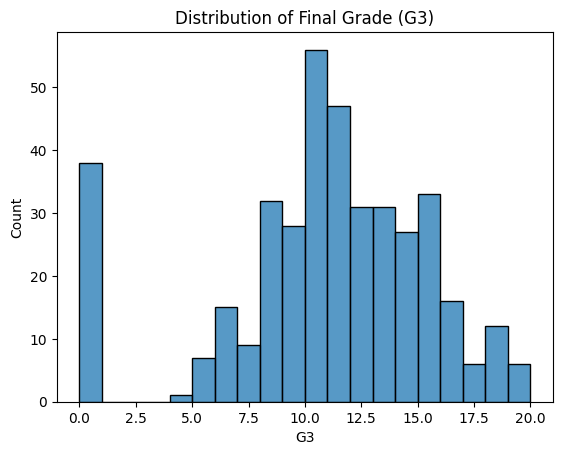

In [7]:
sns.histplot(mat["G3"], bins=20)
plt.title("Distribution of Final Grade (G3)")
plt.show()

In [8]:
corr = mat.corr(numeric_only=True)["G3"].sort_values(ascending=False)
print(corr)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


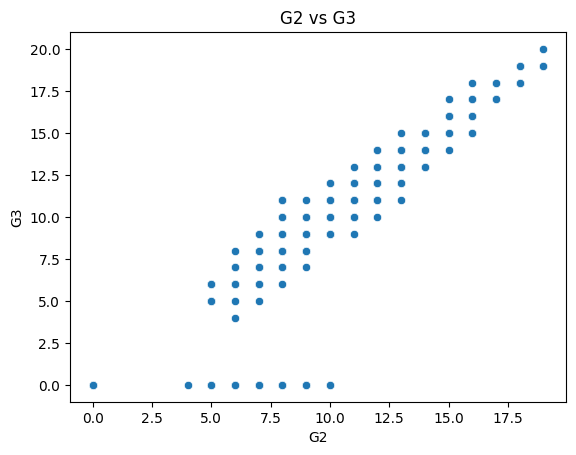

In [9]:
sns.scatterplot(x="G2", y="G3", data=mat)
plt.title("G2 vs G3")
plt.show()

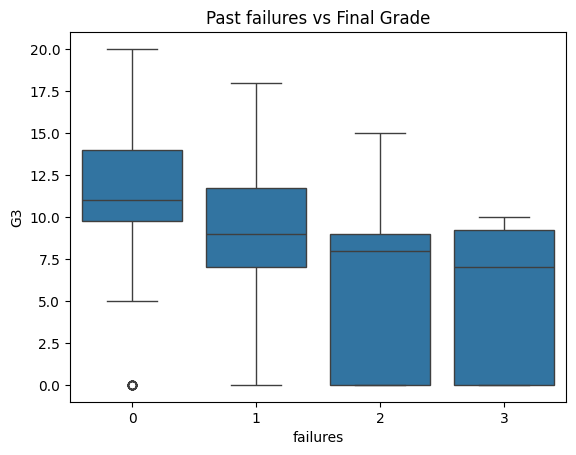

In [10]:
sns.boxplot(x="failures", y="G3", data=mat)
plt.title("Past failures vs Final Grade")
plt.show()

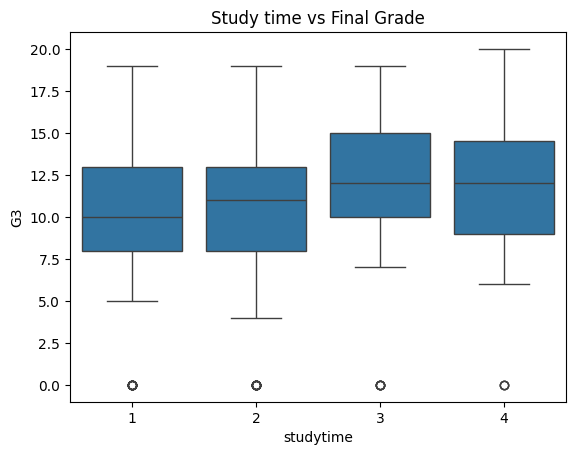

In [11]:
sns.boxplot(x="studytime", y="G3", data=mat)
plt.title("Study time vs Final Grade")
plt.show()

In [12]:
df = pd.get_dummies(mat, drop_first=True)
print(df.shape)

y = df["G3"]
X_full = df.drop(columns=["G3"])
X_early = df.drop(columns=["G3", "G1", "G2"])

from sklearn.model_selection import train_test_split

Xf_train, Xf_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)
Xe_train, Xe_test, _, _ = train_test_split(
    X_early, y, test_size=0.2, random_state=42
)

print(Xf_train.shape, Xf_test.shape)

(395, 42)
(316, 41) (79, 41)


In [13]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dummy = DummyRegressor(strategy="mean")
dummy.fit(Xf_train, y_train)
pred = dummy.predict(Xf_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MAE: 3.64585002403461
R2: -0.009709643515769084


In [14]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(Xf_train, y_train)
pred = ridge.predict(Xf_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))

MAE: 1.6353719773948034
RMSE: 2.369006310817141
R2: 0.7263019769073291


In [15]:
ridge_early = Ridge(alpha=1.0)
ridge_early.fit(Xe_train, y_train)
pred_early = ridge_early.predict(Xe_test)

print("MAE:", mean_absolute_error(y_test, pred_early))
print("R2:", r2_score(y_test, pred_early))

MAE: 3.3889830792813513
R2: 0.14400540660729333


In [16]:
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def evaluate(model, Xtr, Xte, name, version):
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    return {
        "Model": name,
        "Version": version,
        "MAE": round(mean_absolute_error(y_test, pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, pred)), 2),
        "R2": round(r2_score(y_test, pred), 2),
    }

In [17]:
models = {
    "Ridge": Ridge(alpha=1.0),
    "SVR": make_pipeline(StandardScaler(), SVR()),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "MLP (ANN)": make_pipeline(
        StandardScaler(),
        MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42),
    ),
}

In [18]:
results = []
for name, model in models.items():
    results.append(evaluate(model, Xf_train, Xf_test, name, "Full (with G1/G2)"))
    results.append(evaluate(model, Xe_train, Xe_test, name, "Early (no G1/G2)"))

results_df = pd.DataFrame(results)
results_df

,Model,Version,MAE,RMSE,R2
0,Ridge,Full (with G1/G2),1.64,2.37,0.73
1,Ridge,Early (no G1/G2),3.39,4.19,0.14
2,SVR,Full (with G1/G2),1.84,2.73,0.64
3,SVR,Early (no G1/G2),3.40,4.23,0.13
4,Gradient Boosting,Full (with G1/G2),1.16,2.00,0.80
5,Gradient Boosting,Early (no G1/G2),3.23,4.03,0.21
6,MLP (ANN),Full (with G1/G2),2.02,2.78,0.62
7,MLP (ANN),Early (no G1/G2),4.35,5.27,-0.35


In [19]:
cluster_cols = ["studytime", "failures", "absences", "Dalc", "Walc", "goout", "G1", "G2", "G3"]
Xc = mat[cluster_cols]

from sklearn.preprocessing import StandardScaler
Xc_scaled = StandardScaler().fit_transform(Xc)

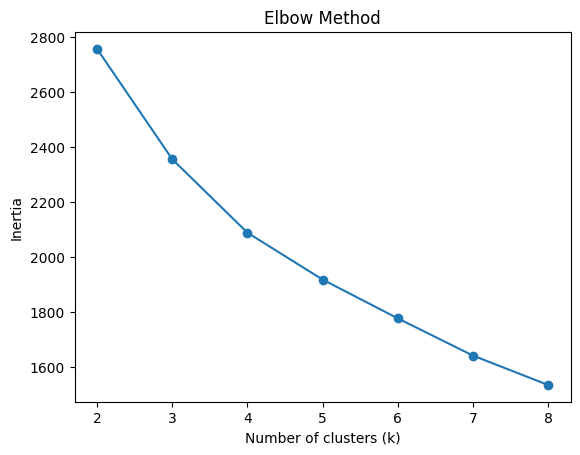

In [20]:
from sklearn.cluster import KMeans

inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Xc_scaled)
    inertias.append(km.inertia_)

plt.plot(range(2, 9), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [21]:
k = 3   # change this to your elbow
km = KMeans(n_clusters=k, random_state=42, n_init=10)
mat["cluster"] = km.fit_predict(Xc_scaled)

print(mat["cluster"].value_counts())
print(mat.groupby("cluster")[cluster_cols].mean().round(2))

cluster
2    177
0    140
1     78
Name: count, dtype: int64
         studytime  failures  absences  Dalc  Walc  goout     G1     G2     G3
cluster                                                                       
0             2.04      0.46      5.03  1.15  1.82   3.02   8.11   7.51   6.51
1             1.71      0.64      8.85  2.81  4.09   4.01   9.56   9.79   9.59
2             2.18      0.10      4.86  1.16  1.87   2.78  13.71  13.65  13.86


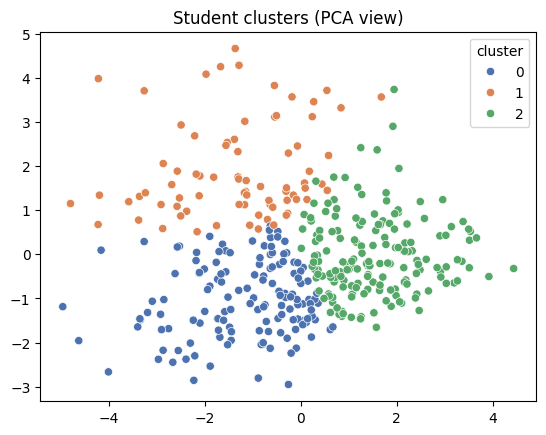

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pts = pca.fit_transform(Xc_scaled)

sns.scatterplot(x=pts[:, 0], y=pts[:, 1], hue=mat["cluster"], palette="deep")
plt.title("Student clusters (PCA view)")
plt.show()